In [1]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Step 2: Load the Dataset

df = pd.read_csv("messy_sales - Sheet1.csv")

In [10]:
# Display first 10 rows
df.head(10)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,January 15 2024,north,tablet,electronics,32,USD 858,########,10%
1,1/30/2024,north,Tablet,Electronics,72,$833.83,########,15 percent
2,2/13/2024,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,4/28/2024,West,Laptop,gadget,thirty,$733.46,########,0.1
4,2/18/2024,EAST,Phone,ELEC,47,USD 373,"40,920",0.1
5,April 03 2024,South,laptop,Gadgets,twenty,670.28,3103,8 percent
6,1/28/2024,north,tablet,electronics,thirty,758.58,"37,789",8 percent
7,March 15 2024,West,Tablet,Gadgets,47,$241.65,"11,484",12%
8,January 09 2024,West,Phone,gadget,thirty,USD 796,"18,486",8 percent
9,2/7/2024,West,laptop,Gadgets,thirty,$996.92,"20,558",0.08


In [11]:
# Step 3: Check Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               200 non-null    object
 1   Region             200 non-null    object
 2   Product            200 non-null    object
 3   Category           200 non-null    object
 4   Units Sold         196 non-null    object
 5   Unit Price         200 non-null    object
 6   Total Sales        197 non-null    object
 7   Profit Margin (%)  200 non-null    object
dtypes: object(8)
memory usage: 12.6+ KB


In [12]:
# Check missing values
df.isnull().sum()

Date                 0
Region               0
Product              0
Category             0
Units Sold           4
Unit Price           0
Total Sales          3
Profit Margin (%)    0
dtype: int64

In [13]:
# Step 4: Handle Missing Values

# Convert columns to numeric
df["Units Sold"] = pd.to_numeric(df["Units Sold"], errors="coerce")
df["Total Sales"] = pd.to_numeric(df["Total Sales"], errors="coerce")


In [14]:
# Fill missing values with average
df["Units Sold"] = df["Units Sold"].fillna(df["Units Sold"].mean())
df["Total Sales"] = df["Total Sales"].fillna(df["Total Sales"].mean())

In [15]:
# Step 5: Clean Column Names

df.columns = df.columns.str.strip()

In [16]:
# Step 6: Fix Date Format

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [17]:
# Step 7: Clean Text Columns

df["Region"] = df["Region"].str.strip().str.title()
df["Product"] = df["Product"].str.strip().str.title()
df["Category"] = df["Category"].str.strip().str.title()

In [18]:
# Step 8: Clean Currency Columns

df["Unit Price"] = df["Unit Price"].astype(str)
df["Unit Price"] = df["Unit Price"].str.replace("$", "", regex=False)
df["Unit Price"] = df["Unit Price"].str.replace(",", "", regex=False)
df["Unit Price"] = pd.to_numeric(df["Unit Price"], errors="coerce")

df["Total Sales"] = df["Total Sales"].astype(str)
df["Total Sales"] = df["Total Sales"].str.replace("$", "", regex=False)
df["Total Sales"] = df["Total Sales"].str.replace(",", "", regex=False)
df["Total Sales"] = pd.to_numeric(df["Total Sales"], errors="coerce")

In [19]:
# Step 9: Fix Profit Margin

df["Profit Margin (%)"] = df["Profit Margin (%)"].astype(str)
df["Profit Margin (%)"] = df["Profit Margin (%)"].str.replace("%", "", regex=False)
df["Profit Margin (%)"] = pd.to_numeric(df["Profit Margin (%)"], errors="coerce")

df["Profit Margin (%)"] = np.where(
    df["Profit Margin (%)"] < 1,
    df["Profit Margin (%)"] * 100,
    df["Profit Margin (%)"]
)

In [20]:
# Step 10: Remove Rows with Missing Data

df_cleaned = df.dropna(subset=["Date", "Total Sales", "Region"])

In [21]:
# Step 11: View Cleaned Dataset

df_cleaned.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,NaN,26096.323077,10.0
5,2024-04-03,South,Laptop,Gadgets,52.307692,670.28,3103.000000,NaN
7,2024-03-15,West,Tablet,Gadgets,47.000000,241.65,26096.323077,12.0
8,2024-01-09,West,Phone,Gadget,52.307692,NaN,26096.323077,NaN
10,2024-01-26,South,Desktop,Elec,52.307692,100.76,26096.323077,8.0


In [22]:
# fill the missing values:

df_cleaned.loc[:, "Unit Price"] = df_cleaned["Unit Price"].fillna(
    df_cleaned["Unit Price"].mean()
)

df_cleaned.loc[:, "Profit Margin (%)"] = df_cleaned["Profit Margin (%)"].fillna(
    df_cleaned["Profit Margin (%)"].mean()
)

In [23]:
# Check dataset information
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 0 to 195
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               65 non-null     datetime64[ns]
 1   Region             65 non-null     object        
 2   Product            65 non-null     object        
 3   Category           65 non-null     object        
 4   Units Sold         65 non-null     float64       
 5   Unit Price         65 non-null     float64       
 6   Total Sales        65 non-null     float64       
 7   Profit Margin (%)  65 non-null     float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 4.6+ KB


In [24]:
df_cleaned.isnull().sum()

Date                 0
Region               0
Product              0
Category             0
Units Sold           0
Unit Price           0
Total Sales          0
Profit Margin (%)    0
dtype: int64

In [25]:
# Save cleaned data as CSV
df_cleaned.to_csv("cleaned_sales.csv", index=False)

C:\Users\91838\AppData\Local\Temp\ipykernel_6480\1401947358.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


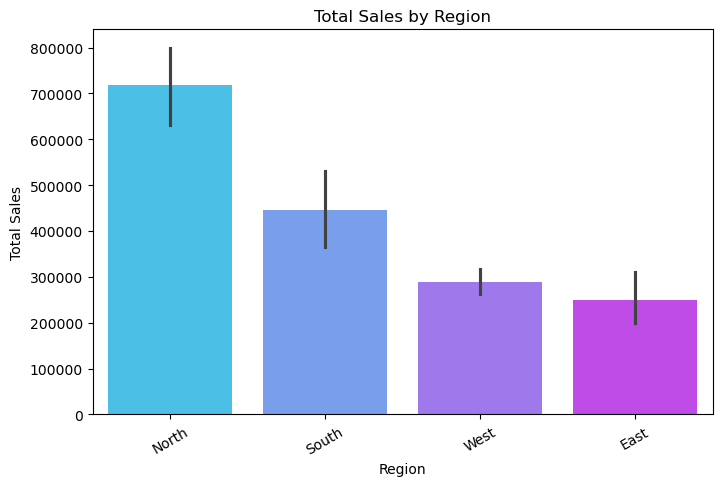

In [26]:
##Total Sales by Region

# Create bar chart
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_cleaned,
    x="Region",
    y="Total Sales",
    estimator=sum,
    palette="cool"
)

plt.title("Total Sales by Region")
plt.xticks(rotation=30)
plt.show()

C:\Users\91838\AppData\Local\Temp\ipykernel_6480\4241372089.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"])


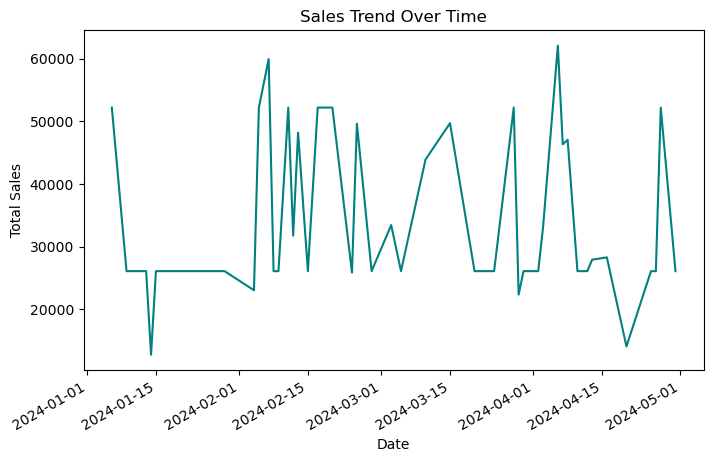

In [27]:
#Sales Trend Over Time

# Convert Date column to datetime
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"])

# Group by Date and calculate Total Sales
sales_trend = df_cleaned.groupby("Date")["Total Sales"].sum()

# Create figure
plt.figure(figsize=(8,5))

# Plot line chart
sales_trend.plot(kind="line", color="teal")

# Add title and labels
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

# Show chart
plt.show()

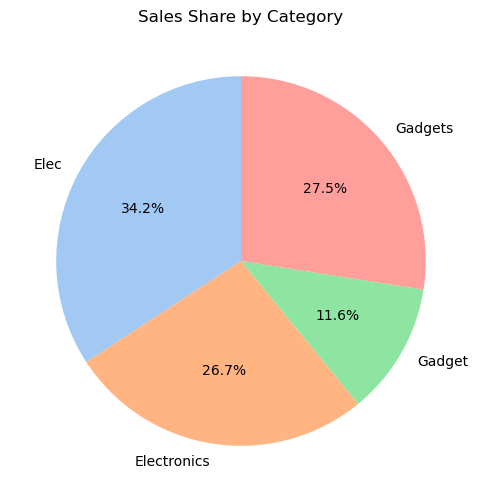

In [28]:
#Sales Share by Category

# Group by Category
category_sales = df_cleaned.groupby("Category")["Total Sales"].sum()

# Create figure
plt.figure(figsize=(6,6))

# Plot pie chart
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)

# Add title
plt.title("Sales Share by Category")

# Remove y-axis label
plt.ylabel("")

# Show chart
plt.show()

C:\Users\91838\AppData\Local\Temp\ipykernel_6480\3229287850.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


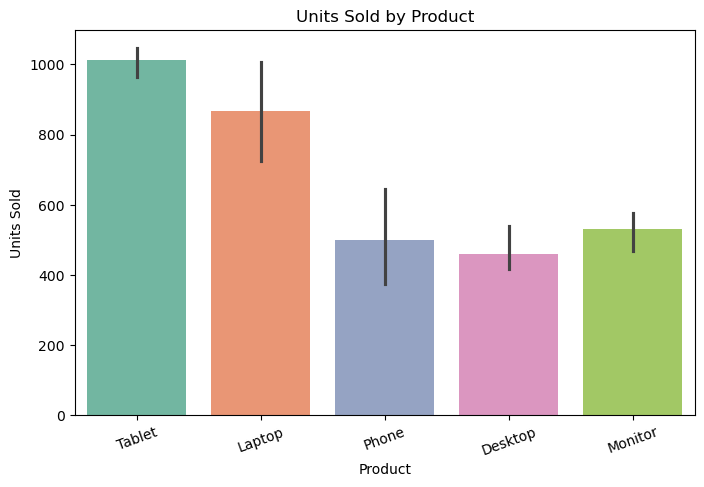

In [30]:
#Units Sold by Product 
#This chart shows which product sold the most units.

# Create figure
plt.figure(figsize=(8,5))

# Bar chart
sns.barplot(
    data=df_cleaned,
    x="Product",
    y="Units Sold",
    estimator=sum,
    palette="Set2"
)

# Add title
plt.title("Units Sold by Product")

# Rotate labels
plt.xticks(rotation=20)

# Show chart
plt.show()


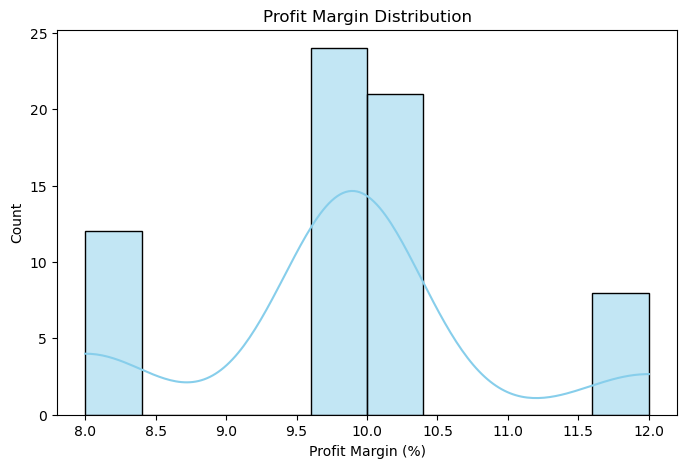

In [31]:
#Profit Margin Distribution

# Create figure
plt.figure(figsize=(8,5))

# Histogram
sns.histplot(
    data=df_cleaned,
    x="Profit Margin (%)",
    bins=10,
    kde=True,
    color="skyblue"
)

# Add title
plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Count")

# Show chart
plt.show()